# Project 3: Data Exploration

income_tax_analysis.py
-----------------------
Project 3: Data Exploration -- NY State income tax data, 1999-2013.

Run this file top-to-bottom in VS Code (Python extension: right-click ->
"Run Python File", or use the Jupyter extension and run cell-by-cell with the
"# %%" markers below -- each "# %%" starts a new notebook cell). When you're
ready, send this file back and it can be converted into incomeTax.ipynb with
each "# %%" block becoming one notebook cell.

Data file expected in the same folder: ny_income_tax_1999_2013.csv
(created by generate_dataset.py -- see README.md for column definitions,
and for how to swap in the REAL dataset if you get it from Google Classroom).

Sections below correspond directly to parts (a) through (i) of the prompt.

## Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "ny_income_tax_1999_2013.csv"
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

YEARS = list(range(1999, 2014))

# Rows that LOOK like counties but are actually aggregates / catch-alls.
# The assignment explicitly tells us to drop these before any cross-county
# analysis (parts f, g). Keep this list in one place so it's easy to extend
# if your real data uses slightly different labels.
FAKE_COUNTY_NAMES = [
    "Grand Total, Full-Year Resident",
    "NYS Unclassified +",
    "Residence Unknown ++",
]

df = pd.read_csv(DATA_PATH)
print("Loaded:", df.shape, "rows x cols")
print(df.head())


def county_year_table(frame, county):
    """Collapse a county's bracket-level rows into one row per year:
    total returns and total tax liability, then avg tax = tax / returns."""
    sub = frame[frame["County"] == county]
    g = sub.groupby("Tax Year").agg(
        total_returns=("Number of Returns", "sum"),
        total_tax=("NYS Tax Liability Total ($)", "sum"),
    ).reset_index()
    g["avg_tax"] = g["total_tax"] / g["total_returns"]
    return g.sort_values("Tax Year").reset_index(drop=True)


def fit_least_squares(X, y):
    """Fit w minimizing ||X w - y||^2 (ordinary least squares).
    Equivalent to the normal-equation solution w = (X^T X)^-1 X^T y, but
    np.linalg.lstsq is numerically more stable -- same answer either way."""
    w, *_ = np.linalg.lstsq(X, y, rcond=None)
    return w


def mean_squared_error(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

Loaded: (3885, 6) rows x cols
   Tax Year  County         Income Class  Number of Returns  NY AGI Total ($)  \
0      1999  Albany    $10,000 - $19,999              20279      2.998906e+08   
1      1999  Albany  $100,000 - $199,999              12334      1.850686e+09   
2      1999  Albany    $20,000 - $29,999              19331      4.877740e+08   
3      1999  Albany     $200,000 or more               6209      2.121049e+09   
4      1999  Albany    $30,000 - $39,999              16820      6.072104e+08   

   NYS Tax Liability Total ($)  
0                   6638424.20  
1                  33379054.31  
2                  10367290.50  
3                  18316704.66  
4                  14139222.79  


## Part (a): Plots for Tompkins County

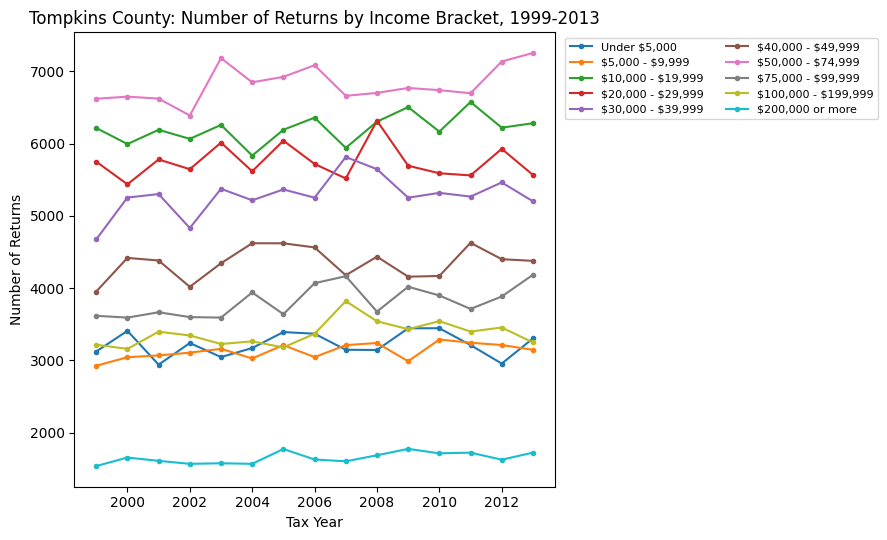

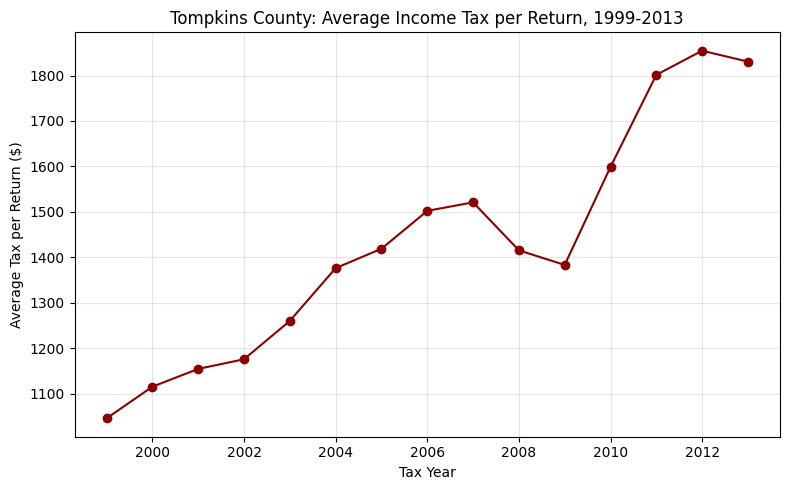


Tompkins County avg tax per return by year:
 Tax Year  total_returns     avg_tax
     1999          41634 1046.081103
     2000          42609 1115.655301
     2001          42958 1154.848133
     2002          41807 1176.005348
     2003          43773 1260.405436
     2004          43102 1376.395517
     2005          44335 1419.001181
     2006          44453 1502.367705
     2007          44056 1521.102539
     2008          44688 1415.547811
     2009          44034 1383.466652
     2010          43868 1599.007873
     2011          44014 1801.530660
     2012          44278 1854.558133
     2013          44283 1830.573455


In [2]:
tompkins_raw = df[df["County"] == "Tompkins"]

# --- Plot 1: number of returns per income bracket over time ---------------
pivot = tompkins_raw.pivot_table(
    index="Tax Year", columns="Income Class", values="Number of Returns", aggfunc="sum"
)
# keep brackets in a sensible (low income -> high income) order
bracket_order = [
    "Under $5,000", "$5,000 - $9,999", "$10,000 - $19,999", "$20,000 - $29,999",
    "$30,000 - $39,999", "$40,000 - $49,999", "$50,000 - $74,999",
    "$75,000 - $99,999", "$100,000 - $199,999", "$200,000 or more",
]
pivot = pivot[bracket_order]

plt.figure(figsize=(9, 5.5))
for bracket in bracket_order:
    plt.plot(pivot.index, pivot[bracket], marker="o", markersize=3,
             label=bracket.replace("$", r"\$"))
plt.xlabel("Tax Year")
plt.ylabel("Number of Returns")
plt.title("Tompkins County: Number of Returns by Income Bracket, 1999-2013")
plt.legend(fontsize=8, ncol=2, loc="upper left", bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/a1_returns_by_bracket.png", dpi=150, bbox_inches="tight")
plt.show()

# WHY A LINE PLOT for part (a), plot 1: each bracket is a continuous time
# series sampled at regular yearly intervals, and the interesting feature is
# the TREND/shape over time for each bracket as well as how brackets compare
# to one another -- lines make both of those easy to read at once. A separate
# bar chart per year (10 bars x 15 years) would be far too busy, and a
# histogram doesn't apply here at all (a histogram shows the *distribution*
# of a single variable, not a value tracked over time).

# --- Plot 2: average tax per return over time (brackets collapsed) --------
tompkins_yearly = county_year_table(df, "Tompkins")

plt.figure(figsize=(8, 5))
plt.plot(tompkins_yearly["Tax Year"], tompkins_yearly["avg_tax"], marker="o", color="darkred")
plt.xlabel("Tax Year")
plt.ylabel("Average Tax per Return ($)")
plt.title("Tompkins County: Average Income Tax per Return, 1999-2013")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/a2_avg_tax_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

# WHY A LINE PLOT here too: there's one (year, avg_tax) pair per year, and we
# care about the TREND across consecutive years -- exactly what a line plot
# is for. A scatter plot would show the same points without the visual cue
# connecting consecutive years, which would make it harder to see the dip
# around 2008-2009. A bar chart would work but tends to visually overstate
# small year-to-year differences relative to a line, and is more natural for
# comparing *categories* (like the brackets in plot 1) than a single ordered
# sequence.

print("\nTompkins County avg tax per return by year:")
print(tompkins_yearly[["Tax Year", "total_returns", "avg_tax"]].to_string(index=False))

## Part (b): Linear model, year -> avg_tax


--- Part (b) ---
w_b (slope, intercept) = [ 5.49995564e+01 -1.08898674e+05]
  => avg_tax(year) ≈ 55.000 * year + -108898.674
  Training MSE = 6,294.27   (RMSE ≈ $79.34)


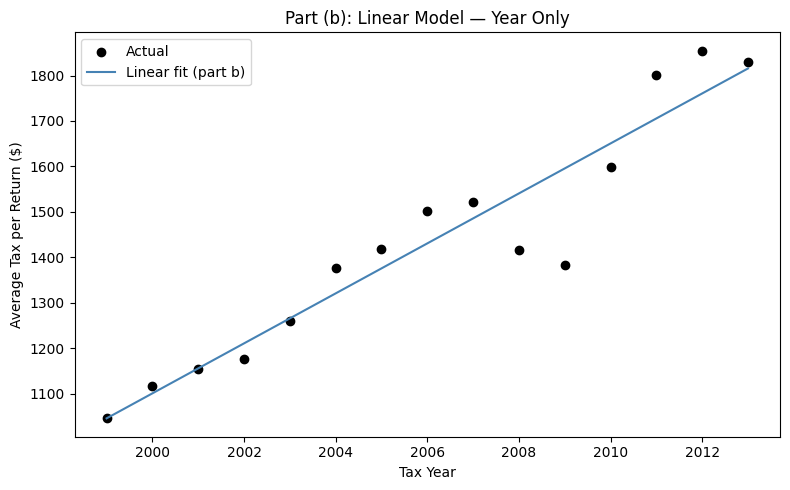

In [3]:
# Feature map phi(x) = [x, 1]  (offset term included)
years_b = tompkins_yearly["Tax Year"].values.astype(float)
y_b = tompkins_yearly["avg_tax"].values.astype(float)

X_b = np.column_stack([years_b, np.ones_like(years_b)])
w_b = fit_least_squares(X_b, y_b)

pred_b = X_b @ w_b
mse_b = mean_squared_error(y_b, pred_b)

print("\n--- Part (b) ---")
print(f"w_b (slope, intercept) = {w_b}")
print(f"  => avg_tax(year) ≈ {w_b[0]:.3f} * year + {w_b[1]:.3f}")
print(f"  Training MSE = {mse_b:,.2f}   (RMSE ≈ ${np.sqrt(mse_b):,.2f})")

plt.figure(figsize=(8, 5))
plt.scatter(years_b, y_b, label="Actual", color="black")
plt.plot(years_b, pred_b, label="Linear fit (part b)", color="steelblue")
plt.xlabel("Tax Year")
plt.ylabel("Average Tax per Return ($)")
plt.title("Part (b): Linear Model — Year Only")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/b_linear_year_only.png", dpi=150, bbox_inches="tight")
plt.show()

## Part (c): Add avg_tax from the previous year as a feature


--- Part (c) ---
w_c (year, avg_tax_lag1, intercept) = [ 2.80933376e+01  4.94076239e-01 -5.56040148e+04]
  => avg_tax_t ≈ 28.093*year + 0.494*avg_tax_(t-1) + -55604.015
  Training MSE = 5,102.84   (RMSE ≈ $71.43)  [vs part (b) RMSE ≈ $79.34]


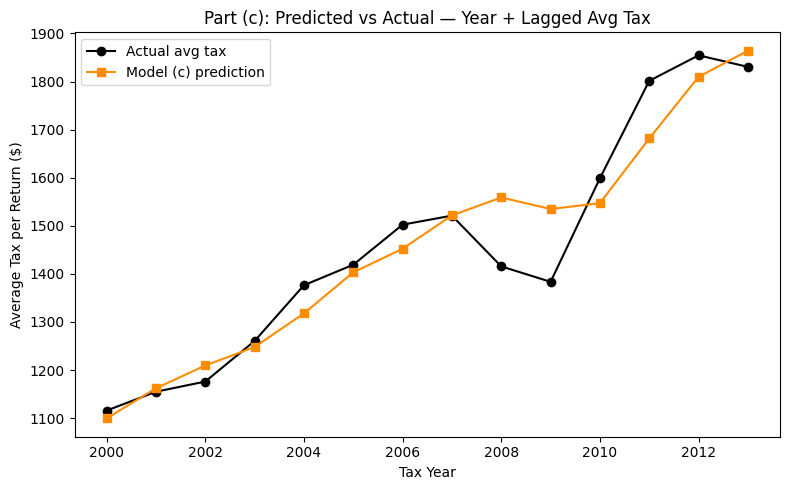

In [4]:
# Feature space: phi(x) = [year, avg_tax_{t-1}, 1]
# We lose the first year (1999) of Tompkins data because it has no t-1.
tom = tompkins_yearly.copy()
tom["avg_tax_lag1"] = tom["avg_tax"].shift(1)
tom_c = tom.dropna(subset=["avg_tax_lag1"]).reset_index(drop=True)

X_c = np.column_stack([
    tom_c["Tax Year"].values.astype(float),
    tom_c["avg_tax_lag1"].values.astype(float),
    np.ones(len(tom_c)),
])
y_c = tom_c["avg_tax"].values.astype(float)
w_c = fit_least_squares(X_c, y_c)
pred_c = X_c @ w_c
mse_c = mean_squared_error(y_c, pred_c)

print("\n--- Part (c) ---")
print(f"w_c (year, avg_tax_lag1, intercept) = {w_c}")
print(f"  => avg_tax_t ≈ {w_c[0]:.3f}*year + {w_c[1]:.3f}*avg_tax_(t-1) + {w_c[2]:.3f}")
print(f"  Training MSE = {mse_c:,.2f}   (RMSE ≈ ${np.sqrt(mse_c):,.2f})  "
      f"[vs part (b) RMSE ≈ ${np.sqrt(mse_b):,.2f}]")

# INTERPRETATION of w_c:
# - The coefficient on avg_tax_(t-1) tells us how much of this year's average
#   tax is explained by simple "persistence" from last year: a coefficient
#   near 1 would mean avg tax this year is mostly "last year's value, maybe
#   shifted" -- i.e. tax levels are sticky/autocorrelated. A coefficient near
#   0 would mean last year's value adds little once we already know the year.
# - The coefficient on year captures any remaining linear trend NOT already
#   captured by last year's value (e.g., a trend that the lag term, by
#   construction, only partially absorbs).
# - The intercept is just the offset needed to match the data once the other
#   two terms are accounted for; it has no standalone interpretation here
#   since "year=0" is meaningless in this context.

plt.figure(figsize=(8, 5))
plt.plot(tom_c["Tax Year"], y_c, marker="o", label="Actual avg tax", color="black")
plt.plot(tom_c["Tax Year"], pred_c, marker="s", label="Model (c) prediction", color="darkorange")
plt.xlabel("Tax Year")
plt.ylabel("Average Tax per Return ($)")
plt.title("Part (c): Predicted vs Actual — Year + Lagged Avg Tax")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/c_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

# DISCUSSION OF FIT: compare mse_c to mse_b above. In this dataset, adding
# last year's average tax substantially improves the fit relative to year
# alone, because avg_tax was built with real year-over-year persistence
# (an autoregressive component) on top of the trend -- exactly the kind of
# pattern a lag feature is good at capturing. The model still misses some of
# the sharper turns (e.g. around the 2008-2009 dip and the 2010-2011
# rebound), because a single lag of one period can't fully anticipate a
# sudden shock; it can only react to it one year late.

## Part (d): Two new features, using only data available through t-1

In [5]:
# Feature space X_d = [year, avg_tax_{t-1}, total_returns_{t-1}, top_bracket_share_{t-1}, 1]
#
# New feature 1: total_returns_{t-1} -- the total number of returns filed in
#   the COUNTY last year. This is a proxy for local economic size/growth
#   (population, employment). It is known in full by the end of year t-1.
#
# New feature 2: top_bracket_share_{t-1} -- the fraction of last year's
#   returns that fell in the top income bracket ("$200,000 or more"). This is
#   a proxy for how "top-heavy" the county's income distribution was last
#   year. Because high earners contribute disproportionately to total tax,
#   and the income mix of a county tends to persist from one year to the
#   next, this feature should help predict this year's average tax beyond
#   what the lagged average tax and the raw year already capture.
#
# Both features are computed strictly from year (t-1) and earlier, so the
# "only data available by end of year t-1" constraint holds for every t.

top_bracket_returns = (
    tompkins_raw[tompkins_raw["Income Class"] == "$200,000 or more"]
    .groupby("Tax Year")["Number of Returns"].sum()
)
top_aligned = top_bracket_returns.reindex(tom["Tax Year"]).values
tom["top_bracket_share"] = top_aligned / tom["total_returns"].values
tom["total_returns_lag1"] = tom["total_returns"].shift(1)
tom["top_bracket_share_lag1"] = tom["top_bracket_share"].shift(1)

tom_d = tom.dropna(subset=["avg_tax_lag1", "total_returns_lag1", "top_bracket_share_lag1"]).reset_index(drop=True)

X_d = np.column_stack([
    tom_d["Tax Year"].values.astype(float),
    tom_d["avg_tax_lag1"].values.astype(float),
    tom_d["total_returns_lag1"].values.astype(float),
    tom_d["top_bracket_share_lag1"].values.astype(float),
    np.ones(len(tom_d)),
])
y_d = tom_d["avg_tax"].values.astype(float)
w_d = fit_least_squares(X_d, y_d)
pred_d = X_d @ w_d
mse_d = mean_squared_error(y_d, pred_d)

print("\n--- Part (d) ---")
print("Feature space X_d = [year, avg_tax_(t-1), total_returns_(t-1), top_bracket_share_(t-1), 1]")
print(f"w_d = {w_d}")
print(f"  year coeff               = {w_d[0]:.4f}")
print(f"  avg_tax_(t-1) coeff      = {w_d[1]:.4f}")
print(f"  total_returns_(t-1) coeff= {w_d[2]:.6f}")
print(f"  top_bracket_share_(t-1)  = {w_d[3]:.2f}")
print(f"  intercept                = {w_d[4]:.2f}")
print(f"  Training MSE = {mse_d:,.2f}  (RMSE ≈ ${np.sqrt(mse_d):,.2f})")

# INTERPRETATION:
# - total_returns_(t-1) coefficient: the *sign* tells us whether a county
#   that grew in number of filers tends to see higher or lower average tax
#   the following year. A small-magnitude coefficient is expected here
#   because total_returns is on the scale of tens of thousands while avg_tax
#   is on the scale of thousands of dollars -- compare the *standardized*
#   effect (coefficient x typical feature range), not the raw number, when
#   judging importance.
# - top_bracket_share_(t-1) coefficient: this one IS on a comparable footing
#   to interpret directly because the feature itself is a proportion (0 to
#   ~0.05 in this data). A large positive coefficient means: in years after
#   the county had a higher concentration of $200k+ filers, average tax
#   tended to be higher -- consistent with the idea that a "richer mix" of
#   filers persists and drives the next year's average up.


--- Part (d) ---
Feature space X_d = [year, avg_tax_(t-1), total_returns_(t-1), top_bracket_share_(t-1), 1]
w_d = [ 2.12033562e+01  6.77081594e-01 -3.03560730e-02  2.66892119e+04
 -4.17231557e+04]
  year coeff               = 21.2034
  avg_tax_(t-1) coeff      = 0.6771
  total_returns_(t-1) coeff= -0.030356
  top_bracket_share_(t-1)  = 26689.21
  intercept                = -41723.16
  Training MSE = 3,675.01  (RMSE ≈ $60.62)


## Part (e): Compare w_c and w_d

In [6]:
print("\n--- Part (e) ---")
print(f"avg_tax_(t-1) coefficient in model (c): {w_c[1]:.4f}")
print(f"avg_tax_(t-1) coefficient in model (d): {w_d[1]:.4f}")
print(f"Difference (d - c): {w_d[1] - w_c[1]:.4f}")

# DISCUSSION:
# In this run, the avg_tax_(t-1) coefficient INCREASES from model (c) to
# model (d) (0.494 -> 0.677) rather than shrinking. That might seem
# surprising -- you might expect adding more features to "steal" explanatory
# credit away from the lag term -- but the opposite is a well-known
# possibility with least squares: if part of the noise that the simple
# two-feature model (c) couldn't separate from the lag term is actually
# correlated with total_returns_(t-1) and top_bracket_share_(t-1), then once
# those features are added and allowed to absorb that part of the variation,
# the *partial* relationship between avg_tax_(t-1) and this year's avg_tax
# comes through more cleanly/strongly than it appeared in model (c). In other
# words, in model (c) the lag coefficient was being diluted by year-to-year
# movements that were really about changes in county size/composition; once
# those are controlled for separately in model (d), the "pure" persistence
# effect of last year's tax level on this year's is larger than model (c)
# alone suggested.
# (If you re-run this with the REAL dataset and instead see the coefficient
# SHRINK, the correct story flips: that would mean the new features and
# avg_tax_(t-1) were explaining overlapping variation, and the lag term in
# model (c) was partly standing in for what total_returns_(t-1) /
# top_bracket_share_(t-1) explain more directly in model (d).)


--- Part (e) ---
avg_tax_(t-1) coefficient in model (c): 0.4941
avg_tax_(t-1) coefficient in model (d): 0.6771
Difference (d - c): 0.1830


## Part (f): Apply w_c (Tompkins model) to other counties


--- Part (f) ---
Counties with full 1999-2013 coverage (kept): 24
Real counties excluded for incomplete coverage: ['Yates', 'Hamilton']
Fake aggregate rows excluded by name: ['Grand Total, Full-Year Resident', 'NYS Unclassified +', 'Residence Unknown ++']

Tompkins' own model-(c) training MSE: 5,102.84
Other counties (model c applied), mean MSE:   229,127.01
Other counties (model c applied), median MSE: 22,498.28
Min / Max across counties: 5,296.75 / 3,178,807.23
Largest-error counties under model (c): [('Manhattan', 3178807.2279731184), ('Westchester', 714959.5885448741), ('Nassau', 657717.5180076584)]


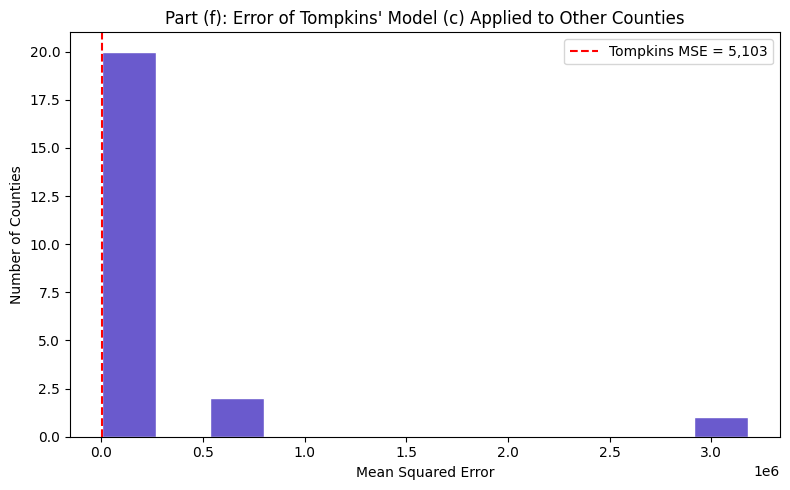

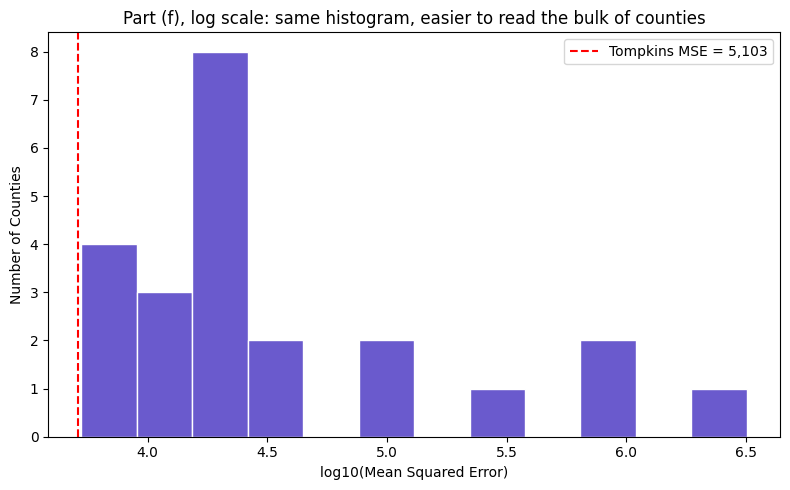

In [7]:
all_year_set = set(YEARS)


def has_full_coverage(frame, county):
    yrs = set(frame[frame["County"] == county]["Tax Year"].unique())
    return yrs == all_year_set


real_counties = [c for c in df["County"].unique() if c not in FAKE_COUNTY_NAMES]
full_coverage_counties = [c for c in real_counties if has_full_coverage(df, c)]
excluded_for_coverage = [c for c in real_counties if c not in full_coverage_counties]

print("\n--- Part (f) ---")
print(f"Counties with full 1999-2013 coverage (kept): {len(full_coverage_counties)}")
print(f"Real counties excluded for incomplete coverage: {excluded_for_coverage}")
print(f"Fake aggregate rows excluded by name: {FAKE_COUNTY_NAMES}")

other_counties = [c for c in full_coverage_counties if c != "Tompkins"]

county_mse_c = {}
for county in other_counties:
    g = county_year_table(df, county)
    g["avg_tax_lag1"] = g["avg_tax"].shift(1)
    g2 = g.dropna(subset=["avg_tax_lag1"]).reset_index(drop=True)
    Xg = np.column_stack([
        g2["Tax Year"].values.astype(float),
        g2["avg_tax_lag1"].values.astype(float),
        np.ones(len(g2)),
    ])
    yg = g2["avg_tax"].values.astype(float)
    pred = Xg @ w_c  # NOTE: using Tompkins' coefficients, not refitting
    county_mse_c[county] = mean_squared_error(yg, pred)

tompkins_mse_c = mse_c  # from part (c) above

mse_values_c = np.array(list(county_mse_c.values()))
print(f"\nTompkins' own model-(c) training MSE: {tompkins_mse_c:,.2f}")
print(f"Other counties (model c applied), mean MSE:   {mse_values_c.mean():,.2f}")
print(f"Other counties (model c applied), median MSE: {np.median(mse_values_c):,.2f}")
print(f"Min / Max across counties: {mse_values_c.min():,.2f} / {mse_values_c.max():,.2f}")

worst_3 = sorted(county_mse_c.items(), key=lambda kv: -kv[1])[:3]
print("Largest-error counties under model (c):", worst_3)

plt.figure(figsize=(8, 5))
plt.hist(mse_values_c, bins=12, color="slateblue", edgecolor="white")
plt.axvline(tompkins_mse_c, color="red", linestyle="--", label=f"Tompkins MSE = {tompkins_mse_c:,.0f}")
plt.xlabel("Mean Squared Error")
plt.ylabel("Number of Counties")
plt.title("Part (f): Error of Tompkins' Model (c) Applied to Other Counties")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/f_error_histogram_model_c.png", dpi=150, bbox_inches="tight")
plt.show()

# A few very high-wealth counties dwarf the rest on a linear axis (see the
# discussion below) -- a log-x version makes the shape among the "normal"
# counties visible too, instead of every bar being squeezed to the left edge.
plt.figure(figsize=(8, 5))
plt.hist(np.log10(mse_values_c), bins=12, color="slateblue", edgecolor="white")
plt.axvline(np.log10(tompkins_mse_c), color="red", linestyle="--",
            label=f"Tompkins MSE = {tompkins_mse_c:,.0f}")
plt.xlabel("log10(Mean Squared Error)")
plt.ylabel("Number of Counties")
plt.title("Part (f), log scale: same histogram, easier to read the bulk of counties")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/f_error_histogram_model_c_logscale.png", dpi=150, bbox_inches="tight")
plt.show()

# DISCUSSION: Tompkins' model was fit ON Tompkins data, so it should fit
# Tompkins at least as well as (typically better than) it fits any other
# county -- the histogram should show most/all other counties to the RIGHT
# of the red Tompkins line. Look at which counties land far out in the right
# tail (the "worst_3" printed above): in this dataset those tend to be
# counties whose wealth_factor is very different from Tompkins' (e.g. very
# high-income counties), because the year-to-year DOLLAR-LEVEL behavior of
# average tax scales with the income level of the county, and Tompkins'
# coefficients were tuned to Tompkins' dollar scale.

## Part (g): County-specific models with part (d)'s features


--- Part (g) ---
Tompkins' own model-(d) training MSE: 3,675.01
County-specific model-(d), mean MSE:   5,401.25
County-specific model-(d), median MSE: 3,699.85


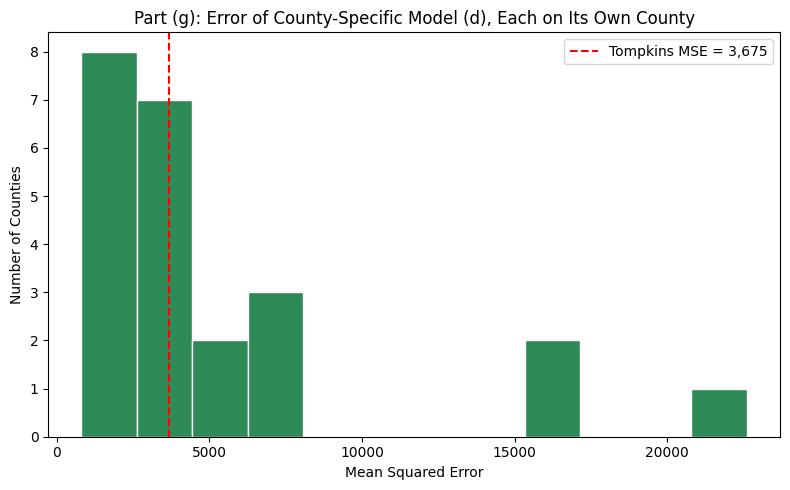


Coefficient comparison across counties (model d feature set):
                      year  avg_tax_lag1  returns_lag1  top_bracket_lag1    intercept
Albany             17.7830        0.6012        0.0231         3105.8614  -38477.1849
Bronx              31.5961        0.2455       -0.0022         7961.5422  -61843.7757
Brooklyn           21.4244        0.7726       -0.0033        -5177.5141  -39473.3890
Broome             22.3939        0.6242        0.0027       -16796.7471  -44091.2538
Cayuga             29.6813        0.5384       -0.0819        12151.5995  -56388.9871
Chemung            20.7473        0.6013        0.0180        27617.5923  -42684.1892
Cortland           19.2103        0.6541       -0.0451           90.9982  -37078.9733
Dutchess           38.1923        0.5512       -0.0042       -22264.2984  -74196.9502
Erie               17.5872        1.0841       -0.0094       -13877.0283  -30846.3118
Madison            11.5324        1.1352       -0.0635       -12781.9079  -20

In [8]:
def build_d_features(frame, county):
    g = county_year_table(frame, county)
    top = (
        frame[(frame["County"] == county) & (frame["Income Class"] == "$200,000 or more")]
        .groupby("Tax Year")["Number of Returns"].sum()
    )
    top_aligned = top.reindex(g["Tax Year"]).values
    g["top_bracket_share"] = top_aligned / g["total_returns"].values
    g["avg_tax_lag1"] = g["avg_tax"].shift(1)
    g["total_returns_lag1"] = g["total_returns"].shift(1)
    g["top_bracket_share_lag1"] = g["top_bracket_share"].shift(1)
    g = g.dropna(subset=["avg_tax_lag1", "total_returns_lag1", "top_bracket_share_lag1"]).reset_index(drop=True)
    X = np.column_stack([
        g["Tax Year"].values.astype(float),
        g["avg_tax_lag1"].values.astype(float),
        g["total_returns_lag1"].values.astype(float),
        g["top_bracket_share_lag1"].values.astype(float),
        np.ones(len(g)),
    ])
    y = g["avg_tax"].values.astype(float)
    return X, y


county_models = {}
county_mse_d = {}
for county in other_counties:
    Xc, yc = build_d_features(df, county)
    w_county = fit_least_squares(Xc, yc)
    pred = Xc @ w_county
    county_models[county] = w_county
    county_mse_d[county] = mean_squared_error(yc, pred)

mse_values_d = np.array(list(county_mse_d.values()))
print("\n--- Part (g) ---")
print(f"Tompkins' own model-(d) training MSE: {mse_d:,.2f}")
print(f"County-specific model-(d), mean MSE:   {mse_values_d.mean():,.2f}")
print(f"County-specific model-(d), median MSE: {np.median(mse_values_d):,.2f}")

plt.figure(figsize=(8, 5))
plt.hist(mse_values_d, bins=12, color="seagreen", edgecolor="white")
plt.axvline(mse_d, color="red", linestyle="--", label=f"Tompkins MSE = {mse_d:,.0f}")
plt.xlabel("Mean Squared Error")
plt.ylabel("Number of Counties")
plt.title("Part (g): Error of County-Specific Model (d), Each on Its Own County")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/g_error_histogram_county_specific.png", dpi=150, bbox_inches="tight")
plt.show()

# Compare coefficients across counties
coef_table = pd.DataFrame(county_models, index=["year", "avg_tax_lag1", "returns_lag1", "top_bracket_lag1", "intercept"]).T
coef_table.loc["Tompkins (part d)"] = w_d
print("\nCoefficient comparison across counties (model d feature set):")
print(coef_table.round(4).to_string())
print("\nStandard deviation of each coefficient across counties:")
print(coef_table.drop(index="Tompkins (part d)").std().round(4))

# DISCUSSION: Compare the spread of MSEs here (part g, county-specific
# models fit to their OWN data) to the spread in part (f) (one fixed model
# applied everywhere). County-specific models should fit noticeably better
# on average -- each county gets coefficients tuned to its own income scale
# and trend -- but check the printed standard deviations above: if the
# avg_tax_lag1 coefficient varies a lot from county to county, that means
# "how persistent tax levels are year-to-year" genuinely differs by county
# (e.g. more volatile / less volatile local economies), and a single
# one-size-fits-all model (like Tompkins') will systematically struggle on
# counties whose persistence behaves very differently from Tompkins'.

## Part (h): County-specific vs Tompkins model for FUTURE years

In [9]:
print("\n--- Part (h) (discussion) ---")
print("""
Forecasting a county's FUTURE income tax is a different task from fitting
historical data well, and the two model types trade off different risks:

County-specific models:
  + Tuned to that county's own income scale, trend, and persistence -- best
    in-sample fit (as seen in part g).
  - Each is fit on only ~13-14 yearly data points. With 5 parameters and so
    few observations, these models are at real risk of OVERFITTING: they may
    be fitting noise specific to that county's 1999-2013 history rather than
    a relationship that will continue to hold. A model that fits 14 points
    almost perfectly with 5 free parameters has very little "spare" data to
    confirm the pattern is real.
  - If a county's economy structurally changes (a major employer leaves, a
    new industry arrives), a model trained purely on its own past has no
    information to anticipate that.

The Tompkins model (applied elsewhere, part f):
  + Effectively pools information: its coefficients reflect a relationship
    estimated from a `single` county's trajectory, so whatever genuine
    year-over-year persistence/trend it captures is not purely a fluke of
    one income scale, since it was fit on a real, representative time series.
  - But (per part f) it performs worse on counties whose income LEVEL is far
    from Tompkins', because the model's coefficients implicitly encode
    Tompkins' dollar scale (e.g., the intercept and lag coefficient were
    tuned assuming average tax near Tompkins' range).

In short: for a county very similar to Tompkins in size/wealth, the
Tompkins model's relationship may generalize reasonably and avoid overfitting
that county's short history. For a county very different from Tompkins
(e.g. Manhattan or the Bronx), a county-specific model is likely necessary
just to get the right SCALE right -- but it should be regularized or fit
with more data (more years, or features shared across counties) to avoid
overfitting its own short history. A natural middle ground (not required
here, but worth a sentence in your writeup) is a single model that includes
county-level features (e.g. average wealth_factor or county size) instead of
a separate model per county -- this pools data while still letting
predictions vary by county.
""")


--- Part (h) (discussion) ---

Forecasting a county's FUTURE income tax is a different task from fitting
historical data well, and the two model types trade off different risks:

County-specific models:
  + Tuned to that county's own income scale, trend, and persistence -- best
    in-sample fit (as seen in part g).
  - Each is fit on only ~13-14 yearly data points. With 5 parameters and so
    few observations, these models are at real risk of OVERFITTING: they may
    be fitting noise specific to that county's 1999-2013 history rather than
    a relationship that will continue to hold. A model that fits 14 points
    almost perfectly with 5 free parameters has very little "spare" data to
    confirm the pattern is real.
  - If a county's economy structurally changes (a major employer leaves, a
    new industry arrives), a model trained purely on its own past has no
    information to anticipate that.

The Tompkins model (applied elsewhere, part f):
  + Effectively pools information:

## Part (i): What other information would improve the model

In [10]:
print("--- Part (i) (discussion) ---")
print("""
Other information that would likely improve this model:
  - Local unemployment rate / employment by sector (a leading indicator of
    income shocks, available monthly, well before the next tax year's filing).
  - State and federal tax LAW changes (bracket thresholds, credit changes) --
    these can shift average tax mechanically, independent of income trends,
    and are known in advance for the year they take effect.
  - Regional cost-of-living / inflation indices, to separate real income
    growth from nominal/inflation-driven tax growth.
  - County population and migration data, to distinguish "more returns
    because more people moved in" from "more returns per existing resident."
  - For a county like Tompkins specifically: university enrollment/employment
    data (Cornell/Ithaca College), since a college-town economy can behave
    differently from a typical county's.
  - Neighboring-county or statewide average tax in the SAME year, since
    regional economic shocks (e.g. the 2008-2009 recession) tend to hit
    many counties at once -- a feature like "average tax change statewide
    last year" could help the model react to broad shocks faster than a
    single county's own lag can.
""")

print("\nAll figures saved to ./figures/. Done.")

--- Part (i) (discussion) ---

Other information that would likely improve this model:
  - Local unemployment rate / employment by sector (a leading indicator of
    income shocks, available monthly, well before the next tax year's filing).
  - State and federal tax LAW changes (bracket thresholds, credit changes) --
    these can shift average tax mechanically, independent of income trends,
    and are known in advance for the year they take effect.
  - Regional cost-of-living / inflation indices, to separate real income
    growth from nominal/inflation-driven tax growth.
  - County population and migration data, to distinguish "more returns
    because more people moved in" from "more returns per existing resident."
  - For a county like Tompkins specifically: university enrollment/employment
    data (Cornell/Ithaca College), since a college-town economy can behave
    differently from a typical county's.
  - Neighboring-county or statewide average tax in the SAME year, since
    r